In [ ]:
pip install ydata-profiling

In [ ]:
pip install openpyxl

In [ ]:
!pip install plotly

In [ ]:
!pip install xgboost

In [ ]:
import numpy as np
import pandas as pd

import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
import plotly.express as px

from ydata_profiling import ProfileReport

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve)
from scipy.stats import uniform, loguniform

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_excel("/content/bank_churn.xlsx")
df.head()

,clientnum,attrition_flag,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,...,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [ ]:
# Crear el reporte
profile = ProfileReport(df, title="Análisis Exploratorio de Datos", explorative=True)

# Mostrar el reporte dentro del notebook
#profile.to_notebook_iframe()

In [ ]:
profile.to_file("reporte_EDA.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 21/21 [00:01<00:00, 20.32it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   clientnum                 10127 non-null  int64  
 1   attrition_flag            10127 non-null  object 
 2   customer_age              10127 non-null  int64  
 3   gender                    10127 non-null  object 
 4   dependent_count           10127 non-null  int64  
 5   education_level           10127 non-null  object 
 6   marital_status            10127 non-null  object 
 7   income_category           10127 non-null  object 
 8   card_category             10127 non-null  object 
 9   months_on_book            10127 non-null  int64  
 10  total_relationship_count  10127 non-null  int64  
 11  months_inactive_12_mon    10127 non-null  int64  
 12  contacts_count_12_mon     10127 non-null  int64  
 13  credit_limit              10127 non-null  float64
 14  total_

In [ ]:
# Valores nulos y duplicados
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nFilas duplicadas: {df.duplicated().sum()}")

Valores nulos por columna:
clientnum                   0
attrition_flag              0
customer_age                0
gender                      0
dependent_count             0
education_level             0
marital_status              0
income_category             0
card_category               0
months_on_book              0
total_relationship_count    0
months_inactive_12_mon      0
contacts_count_12_mon       0
credit_limit                0
total_revolving_bal         0
avg_open_to_buy             0
total_amt_chng_q4_q1        0
total_trans_amt             0
total_trans_ct              0
total_ct_chng_q4_q1         0
avg_utilization_ratio       0
dtype: int64

Filas duplicadas: 0


In [ ]:
# Distribución de churn
print(df['attrition_flag'].value_counts())
print("\nProporción:")
print(df['attrition_flag'].value_counts(normalize=True))

attrition_flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

Proporción:
attrition_flag
Existing Customer    0.83934
Attrited Customer    0.16066
Name: proportion, dtype: float64


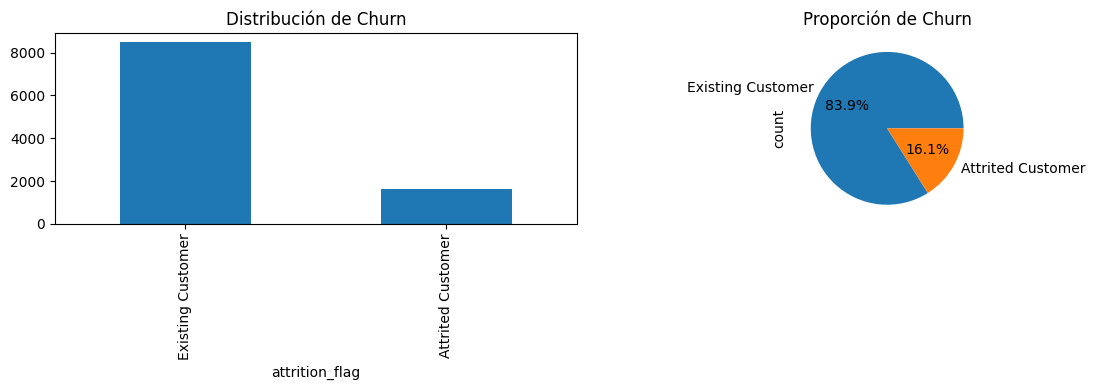

In [ ]:
# Visualización de la distribución de churn
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df['attrition_flag'].value_counts().plot(kind='bar', ax=ax[0])
ax[0].set_title('Distribución de Churn')
df['attrition_flag'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax[1])
ax[1].set_title('Proporción de Churn')
plt.tight_layout()
plt.show()

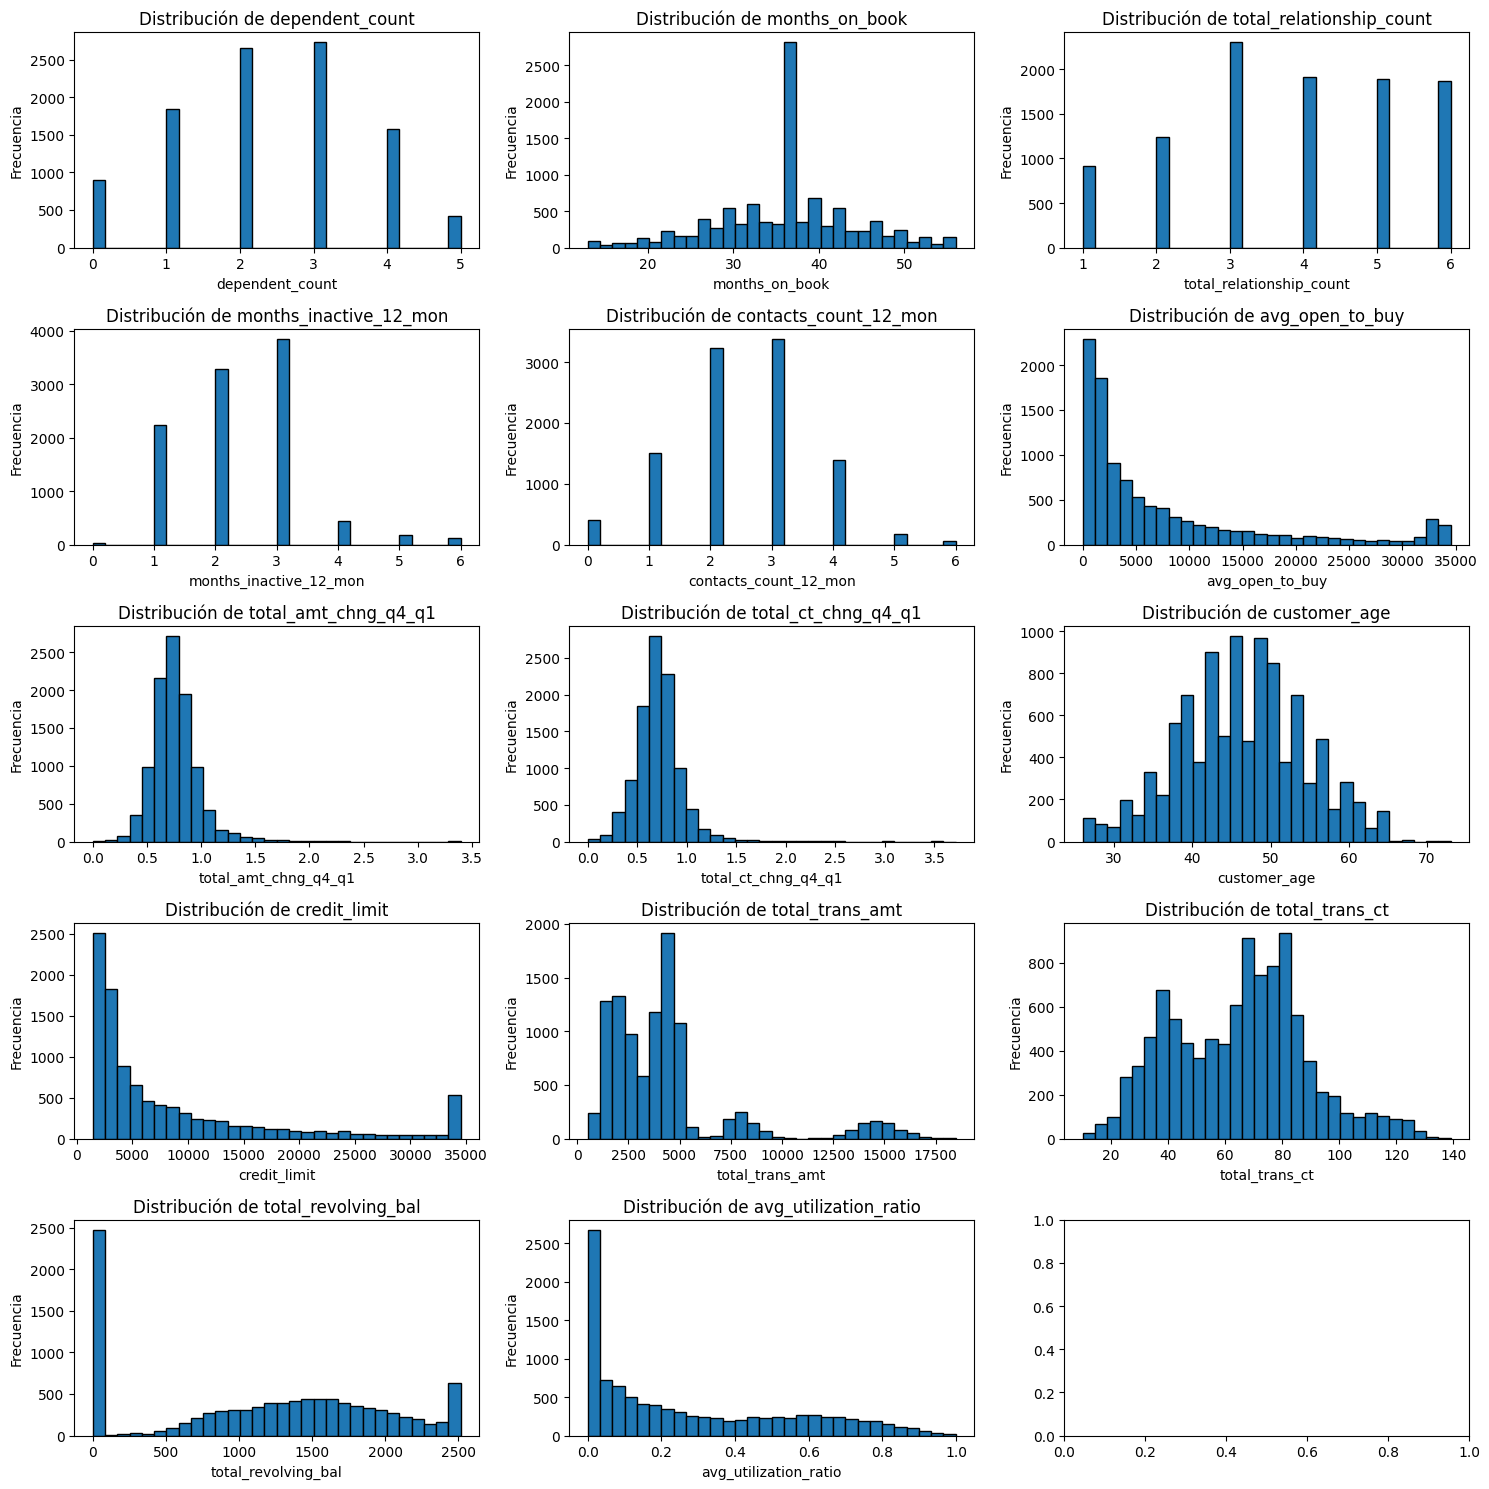

In [ ]:
# Distribuciones de variables numéricas
numerical_cols = ['dependent_count','months_on_book','total_relationship_count','months_inactive_12_mon',
                  'contacts_count_12_mon','avg_open_to_buy','total_amt_chng_q4_q1','total_ct_chng_q4_q1',
                  'customer_age', 'credit_limit', 'total_trans_amt',
                  'total_trans_ct', 'total_revolving_bal', 'avg_utilization_ratio']

fig, axes = plt.subplots(5, 3, figsize=(15, 15))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, edgecolor='black')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

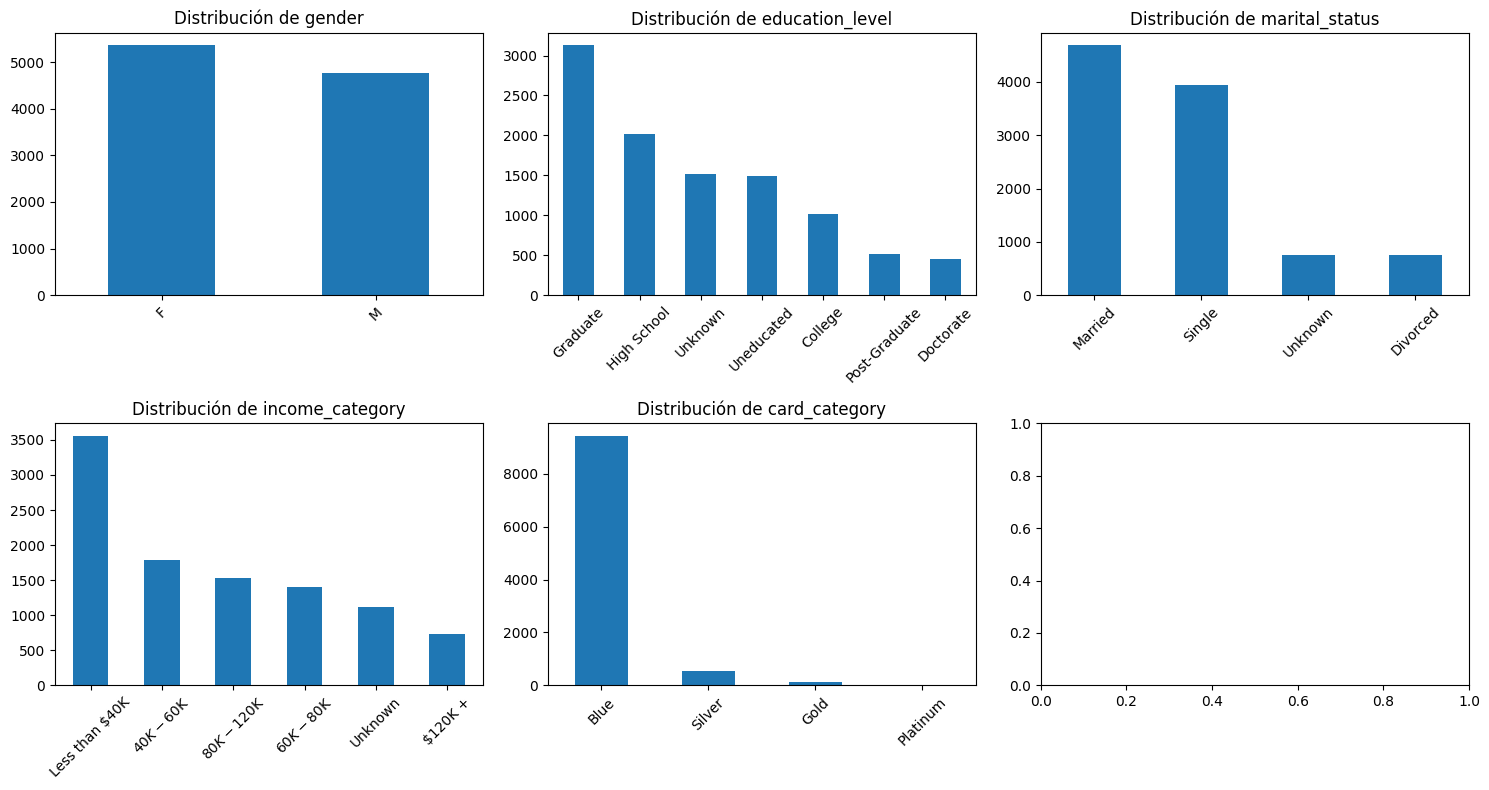

In [ ]:
# Distribuciones de variables categóricas
categorical_cols = ['gender', 'education_level', 'marital_status',
                    'income_category', 'card_category']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

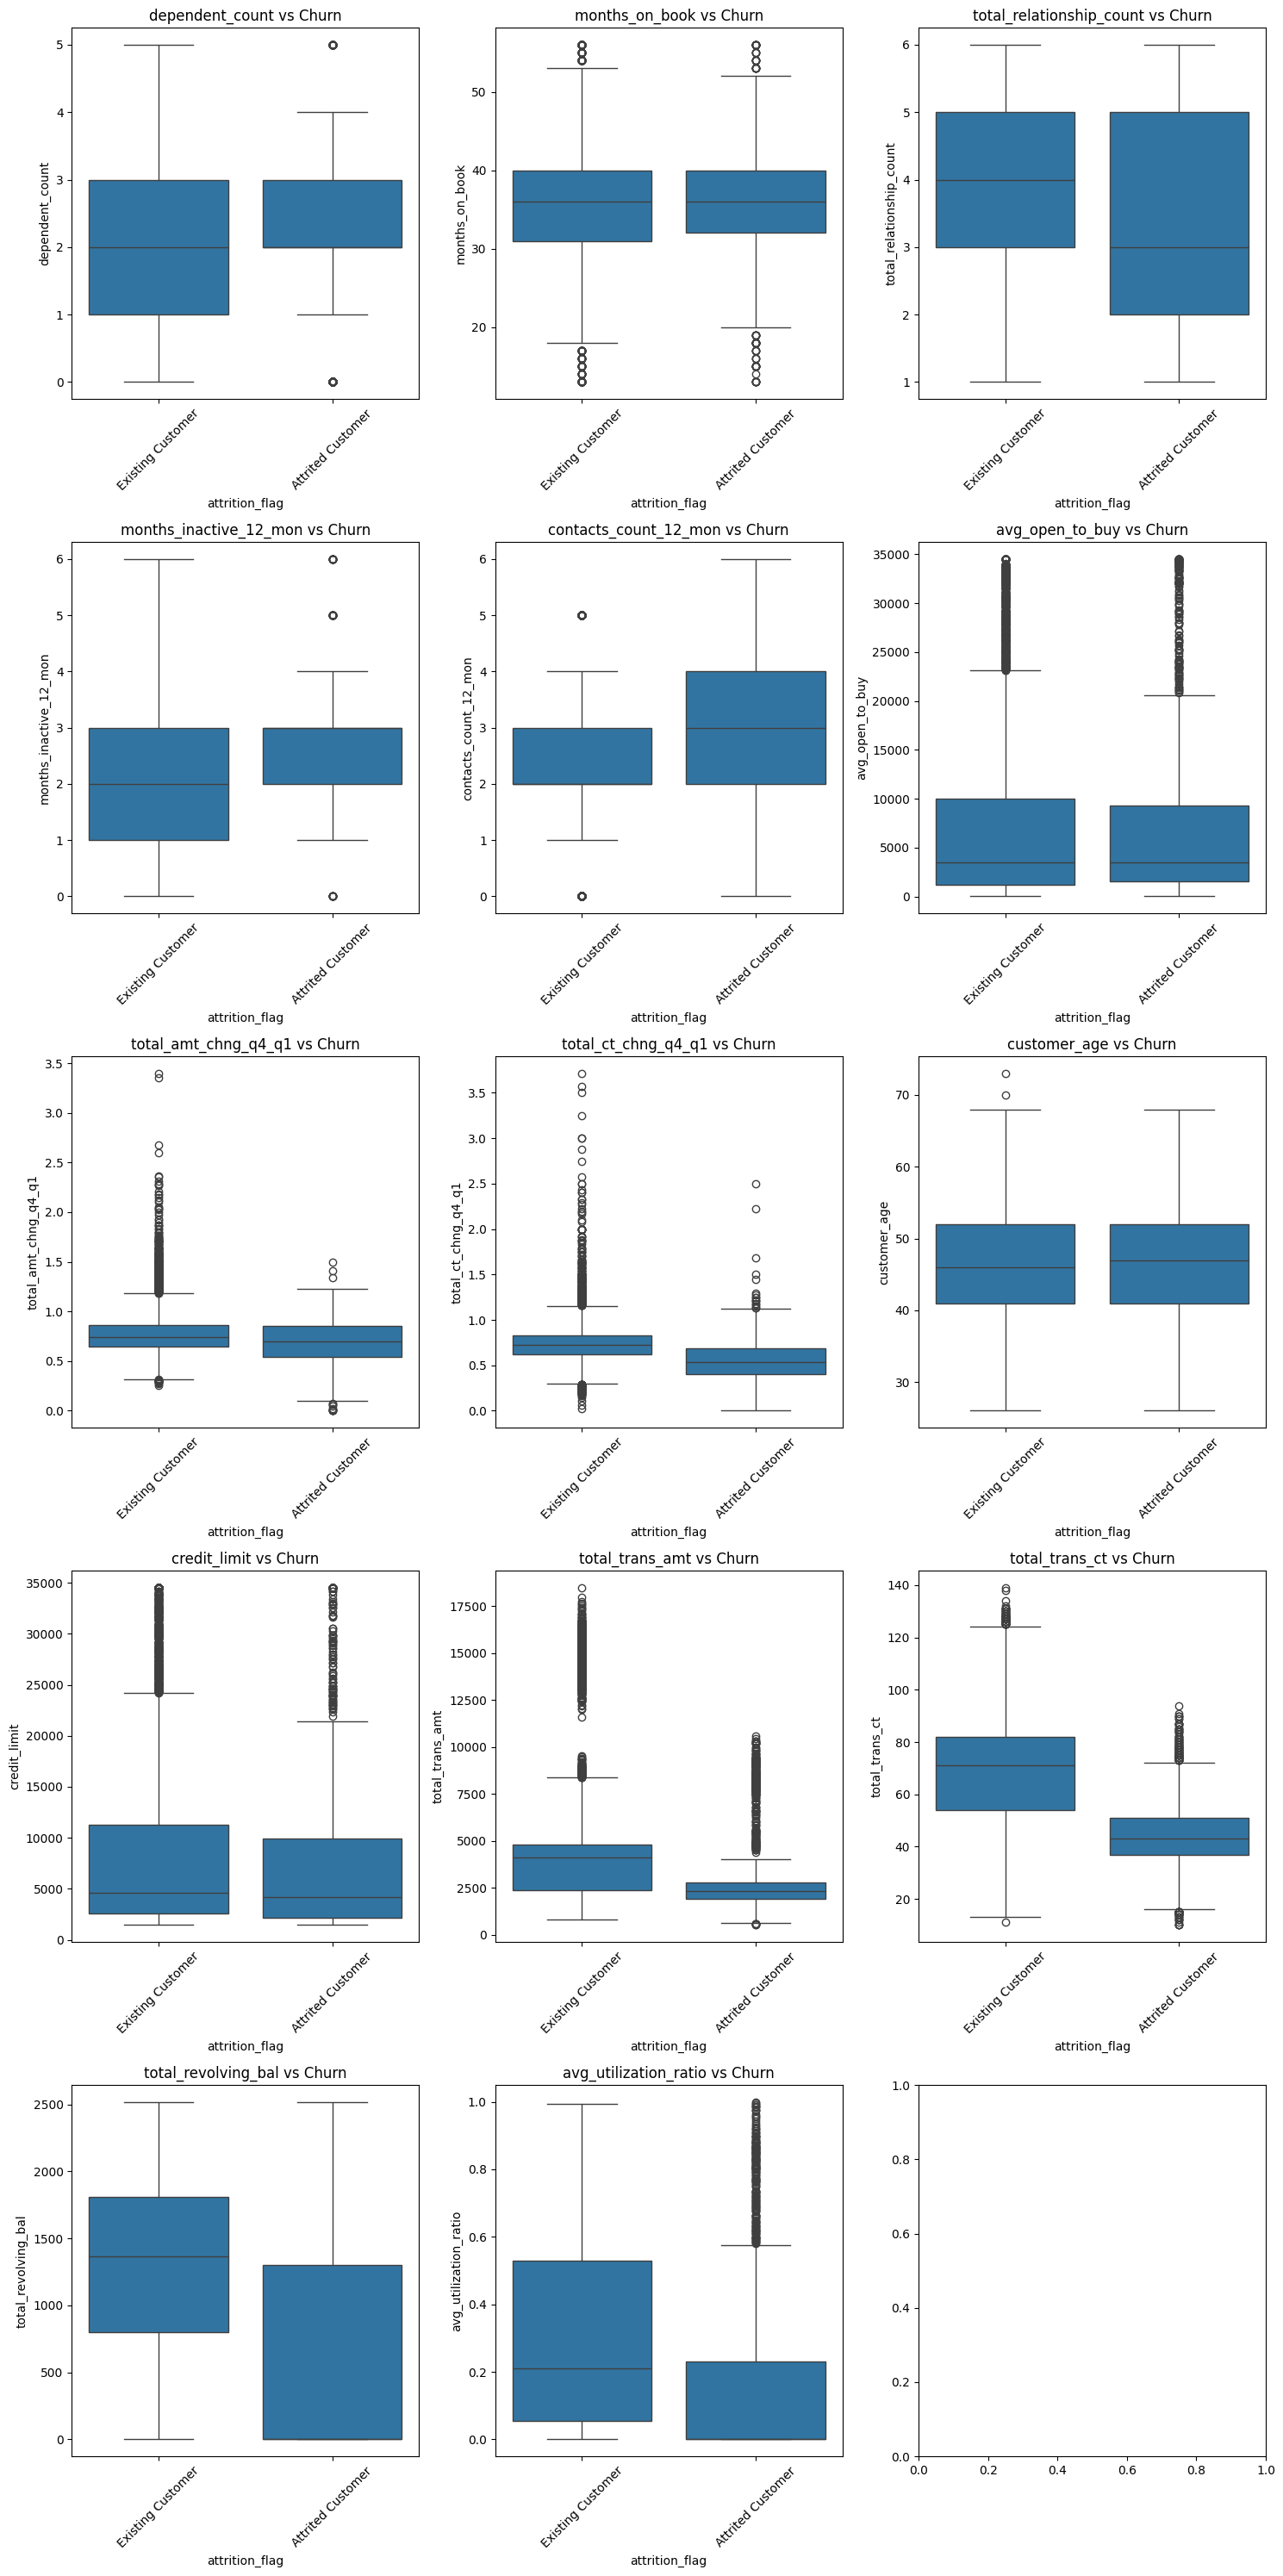


dependent_count:
                    count      mean       std  min  25%  50%  75%  max
attrition_flag                                                        
Attrited Customer  1627.0  2.402581  1.275010  0.0  2.0  2.0  3.0  5.0
Existing Customer  8500.0  2.335412  1.303229  0.0  1.0  2.0  3.0  5.0

months_on_book:
                    count       mean       std   min   25%   50%   75%   max
attrition_flag                                                              
Attrited Customer  1627.0  36.178242  7.796548  13.0  32.0  36.0  40.0  56.0
Existing Customer  8500.0  35.880588  8.021810  13.0  31.0  36.0  40.0  56.0

total_relationship_count:
                    count      mean       std  min  25%  50%  75%  max
attrition_flag                                                        
Attrited Customer  1627.0  3.279656  1.577782  1.0  2.0  3.0  5.0  6.0
Existing Customer  8500.0  3.914588  1.528949  1.0  3.0  4.0  5.0  6.0

months_inactive_12_mon:
                    count      mean  

In [ ]:
#Análisis Bivariado - Variables Numéricas vs Churn
# Boxplots comparativos
fig, axes = plt.subplots(5, 3, figsize=(15, 30))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x='attrition_flag', y=col, ax=axes[i])
    axes[i].set_title(f'{col} vs Churn')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Estadísticas por grupo
for col in numerical_cols:
    print(f"\n{col}:")
    print(df.groupby('attrition_flag')[col].describe())

In [ ]:
#Análisis Bivariado - Variables Numéricas vs Churn
# Boxplots comparativos

for col in numerical_cols:
    fig = px.box(
        df,
        x='attrition_flag',
        y=col,
        color='attrition_flag',
        points='outliers',  # 'all' muestra todos, 'outliers' solo los atípicos
        title=f'{col} vs Churn',
        hover_data=['clientnum']
    )
    fig.update_layout(
        xaxis_title="Estado del cliente",
        yaxis_title=col,
        legend_title="Churn",
        width=600,
        height=400
    )
    fig.show()

    # Opcional: Mostrar estadísticas
    print(f"\nEstadísticas de {col}:")
    print(df.groupby('attrition_flag')[col].describe().round(2))
    print("-"*50)

/usr/local/lib/python3.12/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.





Estadísticas de dependent_count:
                    count  mean   std  min  25%  50%  75%  max
attrition_flag                                                
Attrited Customer  1627.0  2.40  1.28  0.0  2.0  2.0  3.0  5.0
Existing Customer  8500.0  2.34  1.30  0.0  1.0  2.0  3.0  5.0
--------------------------------------------------



Estadísticas de months_on_book:
                    count   mean   std   min   25%   50%   75%   max
attrition_flag                                                      
Attrited Customer  1627.0  36.18  7.80  13.0  32.0  36.0  40.0  56.0
Existing Customer  8500.0  35.88  8.02  13.0  31.0  36.0  40.0  56.0
--------------------------------------------------



Estadísticas de total_relationship_count:
                    count  mean   std  min  25%  50%  75%  max
attrition_flag                                                
Attrited Customer  1627.0  3.28  1.58  1.0  2.0  3.0  5.0  6.0
Existing Customer  8500.0  3.91  1.53  1.0  3.0  4.0  5.0  6.0
--------------------------------------------------



Estadísticas de months_inactive_12_mon:
                    count  mean   std  min  25%  50%  75%  max
attrition_flag                                                
Attrited Customer  1627.0  2.69  0.90  0.0  2.0  3.0  3.0  6.0
Existing Customer  8500.0  2.27  1.02  0.0  1.0  2.0  3.0  6.0
--------------------------------------------------


...


Estadísticas de credit_limit:
                    count     mean      std     min     25%     50%       75%  \
attrition_flag                                                                  
Attrited Customer  1627.0  8136.04  9095.33  1438.3  2114.0  4178.0   9933.50   
Existing Customer  8500.0  8726.88  9084.97  1438.3  2602.0  4643.5  11252.75   

                       max  
attrition_flag              
Attrited Customer  34516.0  
Existing Customer  34516.0  
--------------------------------------------------



Estadísticas de total_trans_amt:
                    count     mean      std    min      25%     50%      75%  \
attrition_flag                                                                 
Attrited Customer  1627.0  3095.03  2308.23  510.0  1903.50  2329.0  2772.00   
Existing Customer  8500.0  4654.66  3512.77  816.0  2384.75  4100.0  4781.25   

                       max  
attrition_flag              
Attrited Customer  10583.0  
Existing Customer  18484.0  
--------------------------------------------------



Estadísticas de total_trans_ct:
                    count   mean    std   min   25%   50%   75%    max
attrition_flag                                                        
Attrited Customer  1627.0  44.93  14.57  10.0  37.0  43.0  51.0   94.0
Existing Customer  8500.0  68.67  22.92  11.0  54.0  71.0  82.0  139.0
--------------------------------------------------



Estadísticas de total_revolving_bal:
                    count     mean     std  min    25%     50%     75%     max
attrition_flag                                                                
Attrited Customer  1627.0   672.82  921.39  0.0    0.0     0.0  1303.5  2517.0
Existing Customer  8500.0  1256.60  757.75  0.0  800.0  1364.0  1807.0  2517.0
--------------------------------------------------



Estadísticas de avg_utilization_ratio:
                    count  mean   std  min   25%   50%   75%   max
attrition_flag                                                    
Attrited Customer  1627.0  0.16  0.26  0.0  0.00  0.00  0.23  1.00
Existing Customer  8500.0  0.30  0.27  0.0  0.06  0.21  0.53  0.99
--------------------------------------------------


In [ ]:
#Análisis Bivariado - Variables Categóricas vs Churn

# Gráficos de barras agrupadas
for col in categorical_cols:
    ct = pd.crosstab(df[col], df['attrition_flag'])

    fig = px.bar(
        ct,
        barmode='group',
        title=f'{col} vs Churn',
        labels={'value': 'Cantidad', 'variable': 'Estado'}
    )
    fig.update_layout(
        xaxis_title=col,
        yaxis_title='Cantidad de clientes',
        width=600,
        height=400
    )
    fig.show()

    # Tasa de churn por categoría
    ct_percent = pd.crosstab(df[col], df['attrition_flag'], normalize='index') * 100

    fig = px.bar(
        x=ct_percent.index,
        y=ct_percent['Attrited Customer'] if 'Attrited Customer' in ct_percent.columns else [],
        title=f'Tasa de Churn (%) por {col}',
        labels={'x': col, 'y': 'Tasa de Churn (%)'},
        text_auto='.1f'
    )
    fig.update_layout(width=600, height=400)
    fig.show()

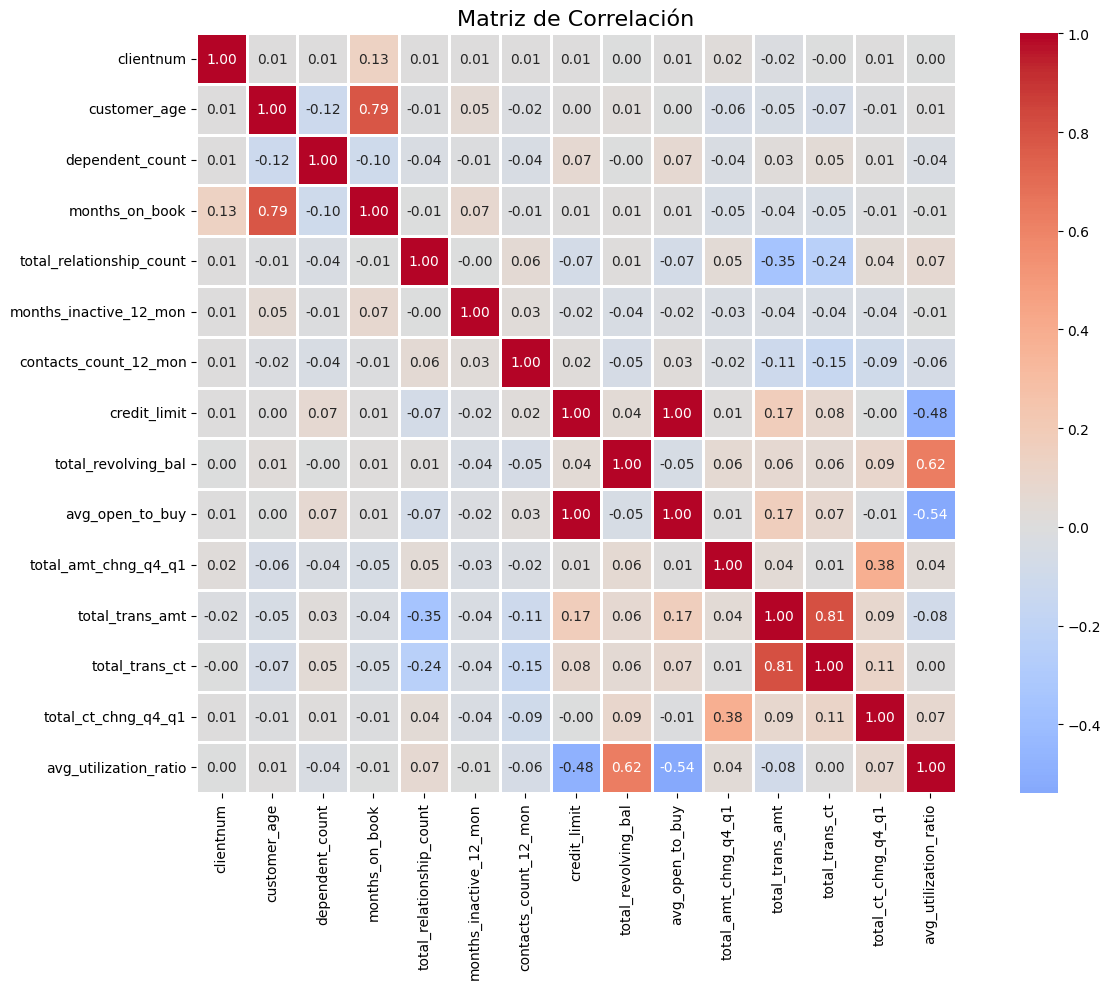


Top correlaciones con total_trans_amt:
total_trans_amt           1.000000
total_trans_ct            0.807192
credit_limit              0.171730
avg_open_to_buy           0.165923
total_ct_chng_q4_q1       0.085581
total_revolving_bal       0.064370
total_amt_chng_q4_q1      0.039678
dependent_count           0.025046
clientnum                -0.019692
months_inactive_12_mon   -0.036982
Name: total_trans_amt, dtype: float64


In [ ]:
# Seleccionar solo columnas numéricas
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Matriz de correlación
plt.figure(figsize=(14, 10))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Matriz de Correlación', fontsize=16)
plt.tight_layout()
plt.show()

# Top correlaciones con variables importantes
print("\nTop correlaciones con total_trans_amt:")
print(correlation_matrix['total_trans_amt'].sort_values(ascending=False).head(10))

In [ ]:
# Eliminar las variables no requeridas y con alta coorrelación
columns_to_drop = ['clientnum', 'credit_limit',
                   'total_trans_amt', 'total_amt_chng_q4_q1', 'total_revolving_bal']

df = df.drop(columns=columns_to_drop)

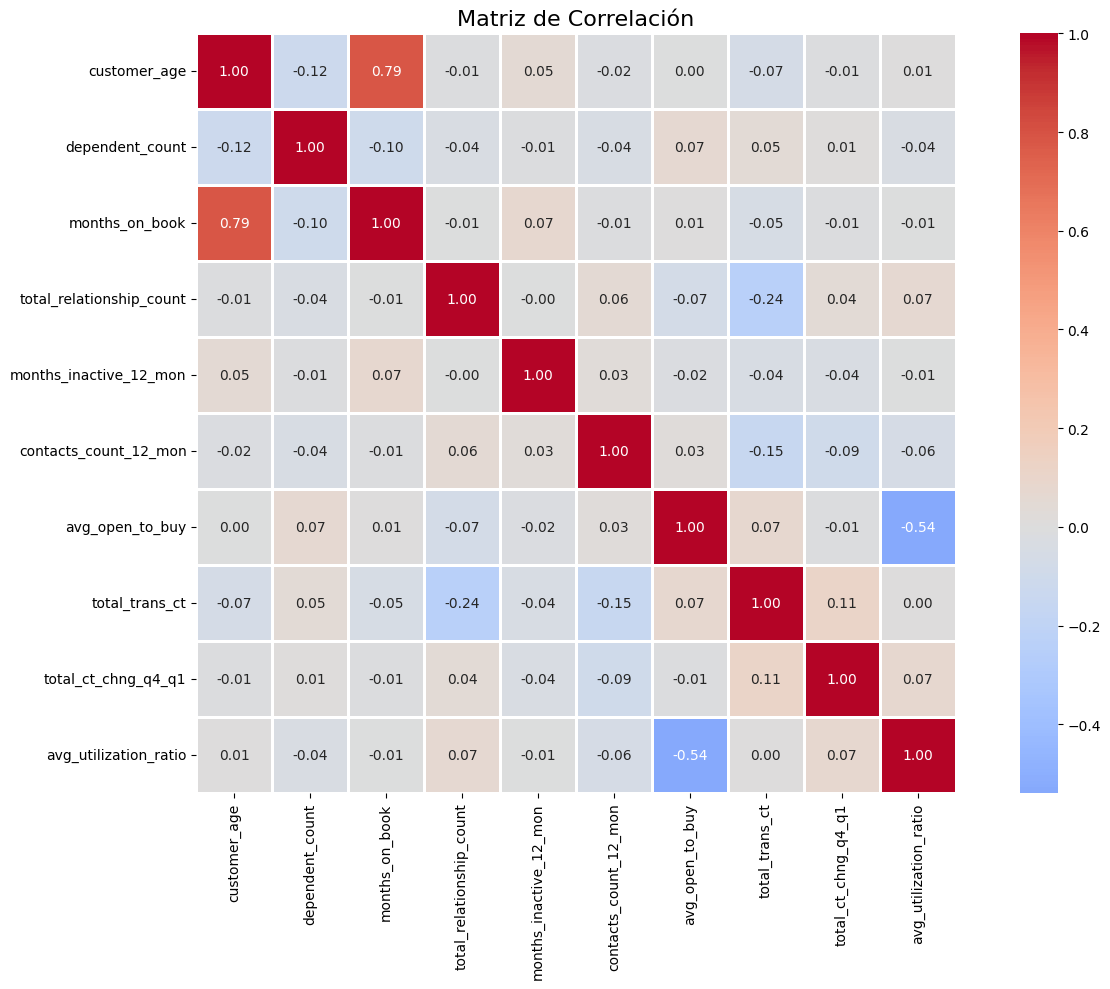

In [ ]:
# Seleccionar solo columnas numéricas
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Matriz de correlación
plt.figure(figsize=(14, 10))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Matriz de Correlación', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Crear variable target (1 = Churn, 0 = No Churn)
df['churn'] = (df['attrition_flag'] == 'Attrited Customer').astype(int)

# Eliminar la columna original
df = df.drop('attrition_flag', axis=1)

# Verificar la distribución
print("Distribución de Churn:")
print(df['churn'].value_counts())
print("\nPorcentaje:")
print(df['churn'].value_counts(normalize=True))

Distribución de Churn:
churn
0    8500
1    1627
Name: count, dtype: int64

Porcentaje:
churn
0    0.83934
1    0.16066
Name: proportion, dtype: float64


In [ ]:
# one-hot encoding variables categoricas (excluyendo 'churn')
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


In [ ]:
print(df.columns.tolist())

['customer_age', 'dependent_count', 'months_on_book', 'total_relationship_count', 'months_inactive_12_mon', 'contacts_count_12_mon', 'avg_open_to_buy', 'total_trans_ct', 'total_ct_chng_q4_q1', 'avg_utilization_ratio', 'churn', 'gender_M', 'education_level_Doctorate', 'education_level_Graduate', 'education_level_High School', 'education_level_Post-Graduate', 'education_level_Uneducated', 'education_level_Unknown', 'marital_status_Married', 'marital_status_Single', 'marital_status_Unknown', 'income_category_$40K - $60K', 'income_category_$60K - $80K', 'income_category_$80K - $120K', 'income_category_Less than $40K', 'income_category_Unknown', 'card_category_Gold', 'card_category_Platinum', 'card_category_Silver']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_age                    10127 non-null  int64  
 1   dependent_count                 10127 non-null  int64  
 2   months_on_book                  10127 non-null  int64  
 3   total_relationship_count        10127 non-null  int64  
 4   months_inactive_12_mon          10127 non-null  int64  
 5   contacts_count_12_mon           10127 non-null  int64  
 6   avg_open_to_buy                 10127 non-null  float64
 7   total_trans_ct                  10127 non-null  int64  
 8   total_ct_chng_q4_q1             10127 non-null  float64
 9   avg_utilization_ratio           10127 non-null  float64
 10  churn                           10127 non-null  int64  
 11  gender_M                        10127 non-null  bool   
 12  education_level_Doctorate       

In [ ]:
y = df['churn']
X = df.drop(columns=['churn'])  # Eliminar la variable objetivo

#Dividir en train y test (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
numerical_cols = ['customer_age', 'dependent_count', 'months_on_book',
                   'total_relationship_count', 'months_inactive_12_mon',
                   'contacts_count_12_mon', 'avg_open_to_buy',
                   'total_trans_ct', 'total_ct_chng_q4_q1','avg_utilization_ratio']

# 4. Estandarizar SOLO las columnas numéricas
scaler = StandardScaler()

# Crear copias para no modificar los originales
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Estandarizar solo las columnas numéricas
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [ ]:
X_train_scaled.head()

,customer_age,dependent_count,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,avg_open_to_buy,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio,...,marital_status_Single,marital_status_Unknown,income_category_$40K - $60K,income_category_$60K - $80K,income_category_$80K - $120K,income_category_Less than $40K,income_category_Unknown,card_category_Gold,card_category_Platinum,card_category_Silver
2856,-1.301232,-1.809900,-1.513205,0.122196,0.646495,-0.411236,-0.783057,-0.961644,-1.093573,2.148867,...,False,False,False,False,False,True,False,False,False,False
6515,-0.299340,0.501503,-0.000700,0.765411,-0.342413,0.489635,1.977862,-1.131083,-0.537244,-1.000072,...,True,False,False,True,False,False,False,False,False,True
7141,-0.048867,-0.268965,-0.756952,1.408625,0.646495,-1.312106,0.370094,1.029259,0.579534,-0.717103,...,False,False,False,False,True,False,False,False,False,False
632,-1.301232,-0.268965,-1.513205,-0.521019,-1.331320,0.489635,-0.651190,-1.004004,-1.427370,0.850111,...,False,False,False,False,False,True,False,False,False,False
3496,0.452079,-1.039432,0.503468,0.122196,-0.342413,0.489635,2.869713,0.309145,0.002601,-0.876727,...,True,False,False,False,False,False,False,False,False,False


In [ ]:
!pip install pycaret

Pycaret

In [ ]:
# Preparar datos
from pycaret.classification import *

# Recombinar train para PyCaret
train_pycaret = X_train_scaled.copy()
train_pycaret['churn'] = y_train.values

test_pycaret = X_test_scaled.copy()
test_pycaret['churn'] = y_test.values

# Setup de PyCaret
clf = setup(
    data=train_pycaret,
    target='churn',
    session_id=123,
    normalize=False,
    transformation=False,
    fold=5,
    test_data=test_pycaret,
    verbose=False
)

RuntimeError: ('Pycaret only supports python 3.9, 3.10, 3.11. Your actual Python version: ', sys.version_info(major=3, minor=12, micro=12, releaselevel='final', serial=0), 'Please DOWNGRADE your Python version.')

In [ ]:
# 4. Comparar modelos
# Lista de modelos a incluir (códigos de PyCaret):
# 'svm' - Support Vector Machine
# 'rf' - Random Forest
# 'ada' - AdaBoost
# 'lr' - Logistic Regression
# 'gbc' - Gradient Boosting
# 'xgboost' - XGBoost
# 'lightgbm' - LightGBM
# 'dt' - Decision Tree
# 'knn' - K Neighbors

modelos_incluir = ['svm', 'rf', 'ada', 'lr', 'gbc', 'lightgbm', 'dt', 'knn']

best_models = compare_models(
    include=modelos_incluir,
    sort='AUC',
    n_select=5
)

# 5. Ver resultados
resultados = pull()
print(resultados)

# 6. Tunear el mejor
best = best_models[0]
tuned_best = tune_model(best, optimize='AUC')

# 7. Evaluar en test
predictions = predict_model(tuned_best, data=test_pycaret)

# 8. Ver métricas finales
plot_model(tuned_best, plot='auc')
plot_model(tuned_best, plot='confusion_matrix')

In [ ]:
# MODELO SVM BASELINE
# Crear modelo baseline con class_weight='balanced' para datos desbalanceados
svm_baseline = SVC(kernel='rbf', C=1.0, gamma='scale',
                   class_weight='balanced',  # ← CLAVE PARA DATOS DESBALANCEADOS
                   random_state=42, probability=True)

# Entrenar
svm_baseline.fit(X_train_scaled, y_train)

# Predicciones
y_pred_baseline = svm_baseline.predict(X_test_scaled)
y_pred_proba_baseline = svm_baseline.predict_proba(X_test_scaled)[:, 1]

In [ ]:
# Métricas de desempeño
print("\nMÉTRICAS DE DESEMPEÑO:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_baseline):.4f}")
print(f"Recall (Sensitivity): {recall_score(y_test, y_pred_baseline):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_baseline):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_baseline):.4f}")

print("\nREPORTE DE CLASIFICACIÓN:")
print(classification_report(y_test, y_pred_baseline,
                          target_names=['No Churn', 'Churn']))


MÉTRICAS DE DESEMPEÑO:
Accuracy: 0.8870
Precision: 0.6086
Recall (Sensitivity): 0.8277
F1-Score: 0.7014
ROC-AUC: 0.9317

REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

    No Churn       0.96      0.90      0.93      1701
       Churn       0.61      0.83      0.70       325

    accuracy                           0.89      2026
   macro avg       0.79      0.86      0.82      2026
weighted avg       0.91      0.89      0.89      2026



In [ ]:
# OPTIMIZACIÓN CON RANDOMIZEDSEARCHCV
# Definición espacio de búsqueda
param_distributions = {
    'C': loguniform(0.01, 100),
    'gamma': loguniform(0.0001, 1),
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'degree': [2, 3, 4, 5],  # Solo para poly
    'class_weight': ['balanced', None]
}

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    SVC(random_state=42, probability=True),
    param_distributions=param_distributions,
    n_iter=50,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Entrenar
random_search.fit(X_train_scaled, y_train)

# Mejores parámetros
print("\nMEJORES HIPERPARÁMETROS:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nMejor ROC-AUC (CV): {random_search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits


KeyboardInterrupt: 

In [ ]:
# MODELO OPTIMIZADO - EVALUACIÓN
# Mejor modelo
best_svm = random_search.best_estimator_

# Predicciones
y_pred_best = best_svm.predict(X_test_scaled)
y_pred_proba_best = best_svm.predict_proba(X_test_scaled)[:, 1]

# Métricas
print("\nMÉTRICAS DE DESEMPEÑO:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_best):.4f}")

print("\nREPORTE DE CLASIFICACIÓN:")
print(classification_report(y_test, y_pred_best,
                          target_names=['No Churn', 'Churn']))

In [ ]:
# VISUALIZACIÓN DE RESULTADOS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[0].set_title('Matriz de Confusión - SVM Optimizado', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Valor Real')
axes[0].set_xlabel('Predicción')

# Añadir porcentajes en la matriz
for i in range(2):
    for j in range(2):
        percentage = cm[i, j] / cm[i].sum() * 100
        axes[0].text(j+0.5, i+0.7, f'({percentage:.1f}%)',
                    ha='center', va='center', fontsize=10, color='red')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_best)
auc_score = roc_auc_score(y_test, y_pred_proba_best)

axes[1].plot(fpr, tpr, color='darkorange', lw=2,
            label=f'ROC curve (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC - SVM Optimizado', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# COMPARACIÓN BASELINE vs OPTIMIZADO

comparison = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'SVM Baseline': [
        accuracy_score(y_test, y_pred_baseline),
        precision_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_baseline),
        roc_auc_score(y_test, y_pred_proba_baseline)
    ],
    'SVM Optimizado': [
        accuracy_score(y_test, y_pred_best),
        precision_score(y_test, y_pred_best),
        recall_score(y_test, y_pred_best),
        f1_score(y_test, y_pred_best),
        roc_auc_score(y_test, y_pred_proba_best)
    ]
})

comparison['Mejora (%)'] = ((comparison['SVM Optimizado'] - comparison['SVM Baseline']) /
                            comparison['SVM Baseline'] * 100).round(2)

print(comparison.round(4))

In [ ]:
# ANÁLISIS DE RENDIMIENTO POR KERNEL

results_df = pd.DataFrame(random_search.cv_results_)
kernel_comparison = results_df.groupby('param_kernel').agg({
    'mean_test_score': ['mean', 'max'],
    'mean_fit_time': 'mean'
}).round(4)

kernel_comparison.columns = ['ROC-AUC Promedio', 'ROC-AUC Máximo', 'Tiempo (s)']
print(kernel_comparison)

# **RandomForest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create a Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model
print("Random Forest Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))

# Visualize the results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[0].set_title('Matriz de Confusión - Random Forest', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Valor real')
axes[0].set_xlabel('Predicción')

# Add percentages to the confusion matrix
for i in range(2):
    for j in range(2):
        percentage = cm_rf[i, j] / cm_rf[i].sum() * 100
        axes[0].text(j+0.5, i+0.7, f'({percentage:.1f}%)',
                    ha='center', va='center', fontsize=10, color='red')

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
auc_score_rf = roc_auc_score(y_test, y_pred_proba_rf)

axes[1].plot(fpr_rf, tpr_rf, color='darkorange', lw=2,
            label=f'ROC curve (AUC = {auc_score_rf:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Random Forest', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**LIGHT GRADIENT BOOSTING MACHINE (LightGBM)**

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
lgbm_model.fit(X_train, y_train)

y_pred_lgbm = lgbm_model.predict(X_test)
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

acc_lgbm = accuracy_score(y_test, y_pred_lgbm)
auc_lgbm = roc_auc_score(y_test, y_prob_lgbm)

print("\n🔹 LightGBM Results")
print("Accuracy:", acc_lgbm)
print("AUC:", auc_lgbm)
print(confusion_matrix(y_test, y_pred_lgbm))
print(classification_report(y_test, y_pred_lgbm))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1302, number of negative: 6799
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000789 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1038
[LightGBM] [Info] Number of data points in the train set: 8101, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.160721 -> initscore=-1.652874
[LightGBM] [Info] Start training from score -1.652874

🔹 LightGBM Results
Accuracy: 0.926949654491609
AUC: 0.9539221272554606
[[1661   40]
 [ 108  217]]
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      1701
           1       0.84      0.67      0.75       325

    accuracy                           0.93      2026
   macro avg       0.89      0.82      0.85     

**GRADIENT BOOSTING CLASSIFIER**



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    random_state=42
)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

acc_gb = accuracy_score(y_test, y_pred_gb)
auc_gb = roc_auc_score(y_test, y_prob_gb)

print("\n🔹 Gradient Boosting Classifier Results")
print("Accuracy:", acc_gb)
print("AUC:", auc_gb)
print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))


🔹 Gradient Boosting Classifier Results
Accuracy: 0.9264560710760118
AUC: 0.9473793696015917
[[1664   37]
 [ 112  213]]
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      1701
           1       0.85      0.66      0.74       325

    accuracy                           0.93      2026
   macro avg       0.89      0.82      0.85      2026
weighted avg       0.92      0.93      0.92      2026



RED NEURONAL

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import scikeras
from scikeras.wrappers import KerasClassifier
from sklearn.pipeline import Pipeline

In [ ]:
!pip install scikeras

In [ ]:
# Definir la arquitectura y las métricas de optimización de la red neuronal

def create_model(data_entrada):
    model = keras.Sequential([
        layers.Dense(128, activation = "relu", input_dim=data_entrada, name = "hidden-dense-128-layer-1"),
        layers.Dropout(0.3),
        layers.Dense(64, activation = "relu", name = "hidden-dense-64-layer-2"),
        layers.Dropout(0.2),
        layers.Dense(1, activation = "sigmoid", name = "output-layer"),
    ])
    # El método de optimización que voy a utilizar
    adam = tf.keras.optimizers.Adam()
    model.compile(loss = "binary_crossentropy", optimizer = adam, metrics=["accuracy"])
    return model

In [ ]:
# nn_estimators = []
# nn_estimators.append(('standardize', StandardScaler())) # Estandarizar los datos de entrada
# nn_estimators.append(('mlp', KerasClassifier(model = create_model(X_train_scaled.shape[1]), epochs = 30, batch_size = 128, validation_split = 0.2)))

# Clasificador_RN = Pipeline(nn_estimators, verbose = False)
# Clasificador_RN.fit(X_train, y_train) # Ingresar datos de entrenamiento, , epochs=30, batch_size=128
# Clasificador_RN.fit(X_train_scaled, y_train)

# Train the KerasClassifier directly on the scaled data
nn_model = KerasClassifier(model=create_model(X_train_scaled.shape[1]), epochs=30, batch_size=128, validation_split=0.2, verbose=1)

nn_model.fit(X_train_scaled, y_train)

In [ ]:
# Make predictions on the scaled test data
y_pred_nn = nn_model.predict(X_test_scaled)
y_pred_proba_nn = nn_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model
print("Neural Network Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nn):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_nn):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_nn):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_nn):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn, target_names=['No Churn', 'Churn']))

In [ ]:
# Visualize the results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm_nn = confusion_matrix(y_test, y_pred_nn)
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[0].set_title('Matriz de Confusión - Red Neural', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Valor Real')
axes[0].set_xlabel('Predicción')

# Add percentages to the confusion matrix
for i in range(2):
    for j in range(2):
        percentage = cm_nn[i, j] / cm_nn[i].sum() * 100
        axes[0].text(j+0.5, i+0.7, f'({percentage:.1f}%)',
                    ha='center', va='center', fontsize=10, color='red')

# ROC Curve
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_pred_proba_nn)
auc_score_nn = roc_auc_score(y_test, y_pred_proba_nn)

axes[1].plot(fpr_nn, tpr_nn, color='darkorange', lw=2,
            label=f'ROC curve (AUC = {auc_score_nn:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Red Neuronal', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()